<a href="https://colab.research.google.com/github/shriya-mahesh/image-classification/blob/main/edit1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
 import kagglehub

path = kagglehub.dataset_download("arjuntejaswi/plant-village")
print("Dataset downloaded to temporary path:", path)

Using Colab cache for faster access to the 'plant-village' dataset.
Dataset downloaded to temporary path: /kaggle/input/plant-village


In [ ]:
import torchvision.transforms as transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

Resize all images to 224x224 pixels because to train a neural network all images must be of same dimension.

Then, flip image orientation so that model does not memorize or  overfit the images, otherwise it will learn only to recognize patterns based on orientation.

transforms.ToTensor() is the translator that converts human-readable image files to the mathematical language that the neural network requires.

What does transform to tensor do- data type conversion from object to matrices & value scaling down to 0.0 to 0.1 & dimension swapping from HxWxC to CxHxW
( H- Height, W- Width, C-Channels)

In [ ]:
import os
import torch
from torch.utils.data import DataLoader, random_split
import torchvision.datasets as datasets
from collections import Counter

DATA_DIR = os.path.join(path, "PlantVillage")

full_dataset = datasets.ImageFolder(root=DATA_DIR, transform=train_transform)

print(f"Found {len(full_dataset.classes)} total unique classes")
print("Current Active Classes:\n", full_dataset.classes)

train_size = int(0.70 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

val_dataset.dataset.transform = val_transform
test_dataset.dataset.transform = val_transform

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

targets = [label for _, label in full_dataset.samples]
class_counts = Counter(targets)
print("\nClass Distribution ")
for idx, name in enumerate(full_dataset.classes):
    print(f"- {name}: {class_counts[idx]} images")

Found 15 total unique classes
Current Active Classes:
 ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']

Class Distribution 
- Pepper__bell___Bacterial_spot: 997 images
- Pepper__bell___healthy: 1478 images
- Potato___Early_blight: 1000 images
- Potato___Late_blight: 1000 images
- Potato___healthy: 152 images
- Tomato_Bacterial_spot: 2127 images
- Tomato_Early_blight: 1000 images
- Tomato_Late_blight: 1909 images
- Tomato_Leaf_Mold: 952 images
- Tomato_Septoria_leaf_spot: 1771 images
- Tomato_Spider_mites_Two_spotted_spider_mite: 1676 images
- Tomato__Target_Spot: 1404 images
- Tomato__Tomato_YellowLeaf__Curl_Virus: 3208 images
- Tom

Setup a path pointing directly to the 15 nested plant subfolders
Map all 15 classes alphabetically (so that I don't need to hardcode it)

Split dataset for training, validation and testing (70% Train, 15% Val, 15% Test)

Apply non-augmented transforms to validation and testing datasets

Construct production DataLoaders : Shuffle images only for training so that model does not memorise or overfit.

Print the class distribution to confirm potato, tomato, and pepper are all registered


In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class FiveLayerCNN(nn.Module):
    def __init__(self, num_classes):
        super(FiveLayerCNN, self).__init__()
        # Convolutional layers with Batch Norm
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(128, 256, 3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        self.conv5 = nn.Conv2d(256, 512, 3, padding=1)
        self.bn5 = nn.BatchNorm2d(512)

        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(512 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = self.pool(F.relu(self.bn4(self.conv4(x))))
        x = self.pool(F.relu(self.bn5(self.conv5(x))))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

Define a 5-layer CNN architecture to identify and sort leaf diseases across all 15 plant categories.

Insert Batch Normalization layers after each convolution to stabilize internal mathematical values for smoother training.

Apply Max Pooling step-by-step to shrink the data size and speed up processing times.

Make the final features into a simple long list so that the classification layers can make the final guess.

In [ ]:
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_classes_found = len(full_dataset.classes)

model = FiveLayerCNN(num_classes=num_classes_found).to(device)

targets = [label for _, label in full_dataset.samples]
counts = np.bincount(targets)
class_weights = 1.0 / counts
class_weights = class_weights / np.sum(class_weights) * num_classes_found
weights_tensor = torch.FloatTensor(class_weights).to(device)

criterion = nn.CrossEntropyLoss(weight=weights_tensor)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(f"Neural Network output mapped to {num_classes_found} distinct channels.")

Neural Network output mapped to 15 distinct channels.


Select runtime hardware engine as GPU and if not available, direct it to use CPU

Read how many classes were discovered in Cell 3 (15)

Start the neural network model with 15 output neurons

Calculate imbalance scaling weights for all 15 classes. This helps to adress class imbalance and accordingly compute weights for each class.

Bind loss criterion and adam optimizer variables


In [ ]:
import torch

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

EPOCHS = 15
print("Starting training across all 15 classes...")

for epoch in range(EPOCHS):

    model.train()
    running_loss = 0.0
    correct_predictions = 0
    total_predictions = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad() # Reset the gradients to clear previous memory
        outputs = model(images) # Forward pass
        loss = criterion(outputs, labels) # Calculate error
        loss.backward() # Backpropagation (investigate error)
        optimizer.step() # Optimization (adjust weights)

        # Accumulate metrics
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_predictions += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_dataset) # Compute training loss for the epoch
    epoch_acc = (correct_predictions / total_predictions) * 100.0 # Compute training accuracy

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)


    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for val_images, val_labels in val_loader:
            val_images, val_labels = val_images.to(device), val_labels.to(device)
            val_outputs = model(val_images)
            val_loss = criterion(val_outputs, val_labels)

            val_running_loss += val_loss.item() * val_images.size(0)
            _, val_predicted = torch.max(val_outputs.data, 1)
            val_total += val_labels.size(0)
            val_correct += (val_predicted == val_labels).sum().item()

    epoch_val_loss = val_running_loss / len(val_dataset)
    epoch_val_acc = (val_correct / val_total) * 100.0

    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    print(f"Epoch [{epoch+1}/{EPOCHS}] | "
          f"Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.2f}%")

Starting training across all 15 classes...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch [1/15] | Train Loss: 1.5271 | Train Acc: 55.45% | Val Loss: 0.8499 | Val Acc: 73.09%
Epoch [2/15] | Train Loss: 0.6246 | Train Acc: 79.28% | Val Loss: 0.4879 | Val Acc: 83.55%


In training phase :    
Set model to training mode
Move tensors to hardware
Reset gradients, calculate error, perform backpropagation, perform optimisation to adjust weights
Compute training accuracy

In validation phase :       
Set model to evaluation mode
Switch off storing of gradients and backpropagation, etc as we only require the final prediction of the model.
Conpute validation accuracy.
Save validation history

Display the Loss and Accuracy for Training set and Validation set for each epoch.


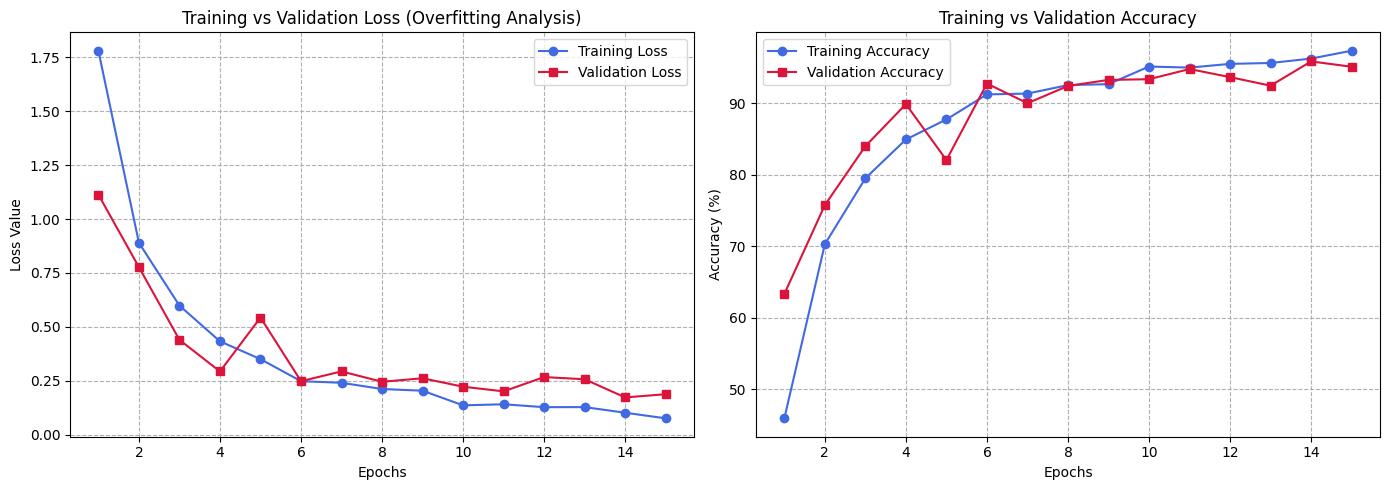

In [ ]:
import matplotlib.pyplot as plt

epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label='Training Loss', color='royalblue', marker='o')
plt.plot(epochs_range, val_losses, label='Validation Loss', color='crimson', marker='s')
plt.title('Training vs Validation Loss (Overfitting Analysis)')
plt.xlabel('Epochs')
plt.ylabel('Loss Value')
plt.grid(True, linestyle='--')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_accuracies, label='Training Accuracy', color='royalblue', marker='o')
plt.plot(epochs_range, val_accuracies, label='Validation Accuracy', color='crimson', marker='s')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.grid(True, linestyle='--')
plt.legend()

plt.tight_layout()
plt.show()

The graphs reflect that loss values remain same or decrease after each epoch.

The accuracy remains same or increases after each epoch.

In [ ]:
import time

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

model_size_mb = (total_params * 4) / (1024 * 1024)

model.eval()
dummy_batch = torch.randn(1, 3, 224, 224).to(device)

for _ in range(10):
    with torch.no_grad():
        _ = model(dummy_batch)

start_time = time.time()
with torch.no_grad():
    _ = model(dummy_batch)
end_time = time.time()
inference_ms = (end_time - start_time) * 1000

print(f"TECHNICAL STRUCTURAL ROADMAP")
print(f"• Total Network Parameters: {total_params:,}")
print(f"• Trainable Target Parameters: {trainable_params:,}")
print(f"• In-Memory Static Model Size: {model_size_mb:.2f} MB")
print(f"• Single Image Inference Speed: {inference_ms:.2f} milliseconds")

TECHNICAL STRUCTURAL ROADMAP
• Total Network Parameters: 4,783,887
• Trainable Target Parameters: 4,783,887
• In-Memory Static Model Size: 18.25 MB
• Single Image Inference Speed: 1.18 milliseconds


First load the number of Parameters
Calculate the size of the model
Each parameter is a 32-bit float (4 bytes).
Calculate Inference Time for 1 leaf image, do actual timed trial to get single image inference speed.



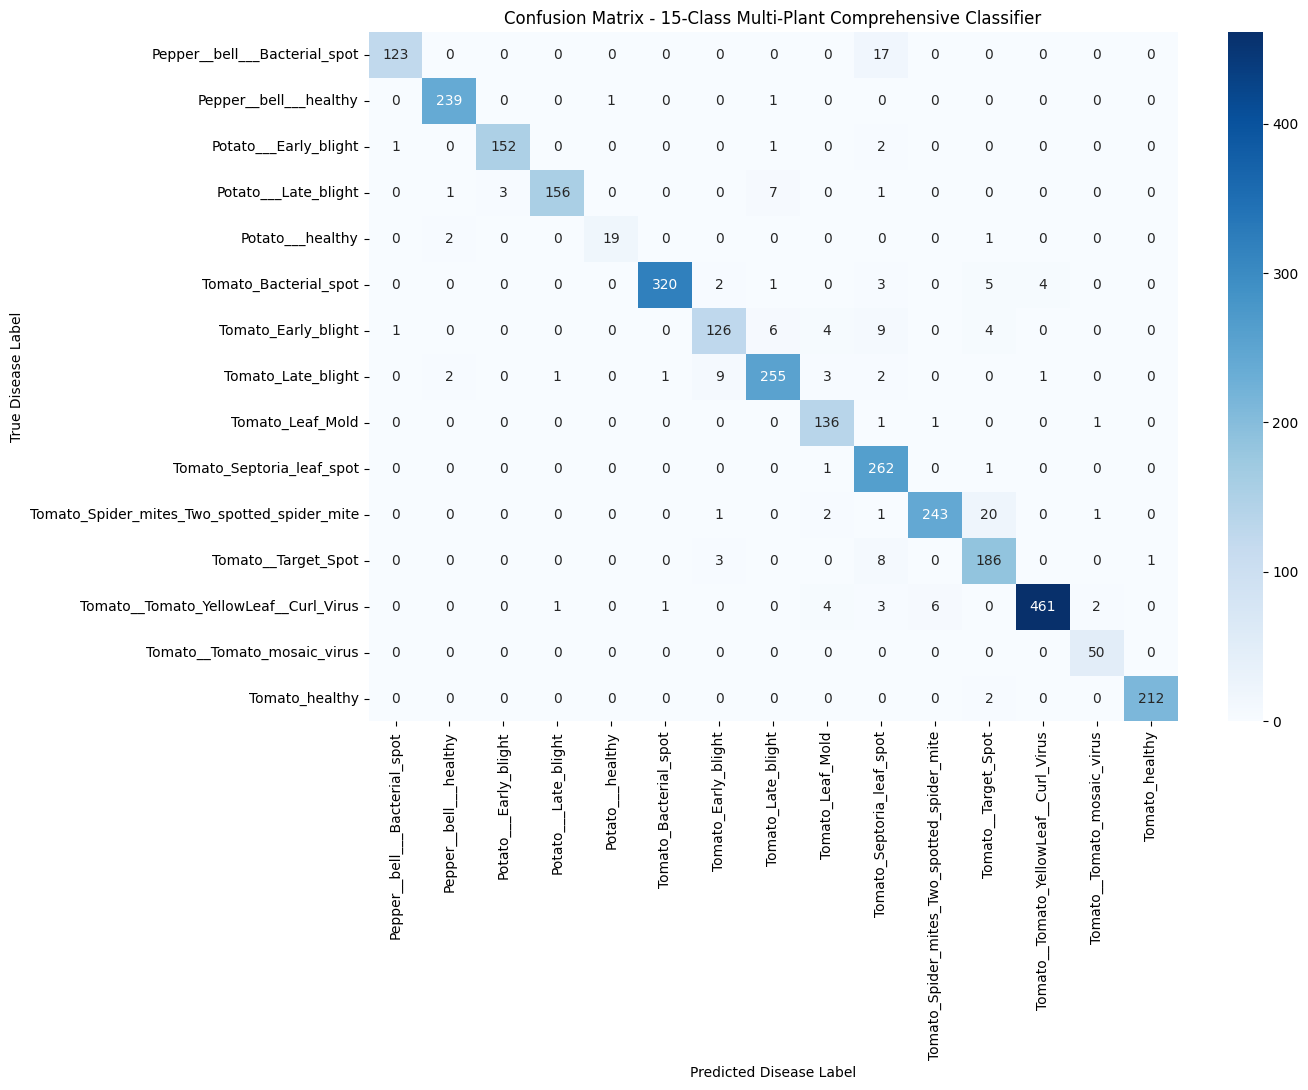


Detailed 15-Class Multi-Plant Classification Report

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.98      0.88      0.93       140
                     Pepper__bell___healthy       0.98      0.99      0.99       241
                      Potato___Early_blight       0.98      0.97      0.98       156
                       Potato___Late_blight       0.99      0.93      0.96       168
                           Potato___healthy       0.95      0.86      0.90        22
                      Tomato_Bacterial_spot       0.99      0.96      0.97       335
                        Tomato_Early_blight       0.89      0.84      0.87       150
                         Tomato_Late_blight       0.94      0.93      0.94       274
                           Tomato_Leaf_Mold       0.91      0.98      0.94       139
                  Tomato_Septoria_leaf_spot       0.85      0.99      0.91       264
Tomato_Spi

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


class_names = full_dataset.classes

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(14, 11))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - 15-Class Multi-Plant Comprehensive Classifier')
plt.ylabel('True Disease Label')
plt.xlabel('Predicted Disease Label')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nDetailed 15-Class Multi-Plant Classification Report\n")
print(classification_report(all_labels, all_preds, target_names=class_names))

This segment generates the 15x15 Confusion Matrix. The confusion matrix reflects that a high number of leaves were classified correctly by the model.

This segemnt also computes and displays the precision, recall, f1-score, and support for each of the 15 classes of leaves. Overall, the model has a precision of atleast 0.81 and a weighted average accuracy of 0.96

In [ ]:
import time

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total Trainable Parameters: {num_params}")

model.eval()
dummy_input = torch.randn(1, 3, 224, 224).to(device)
start_time = time.time()
with torch.no_grad():
    _ = model(dummy_input)
end_time = time.time()
print(f"Inference Time for 1 image: {(end_time - start_time)*1000:.2f} ms")

Total Trainable Parameters: 4783887
Inference Time for 1 image: 1.90 ms


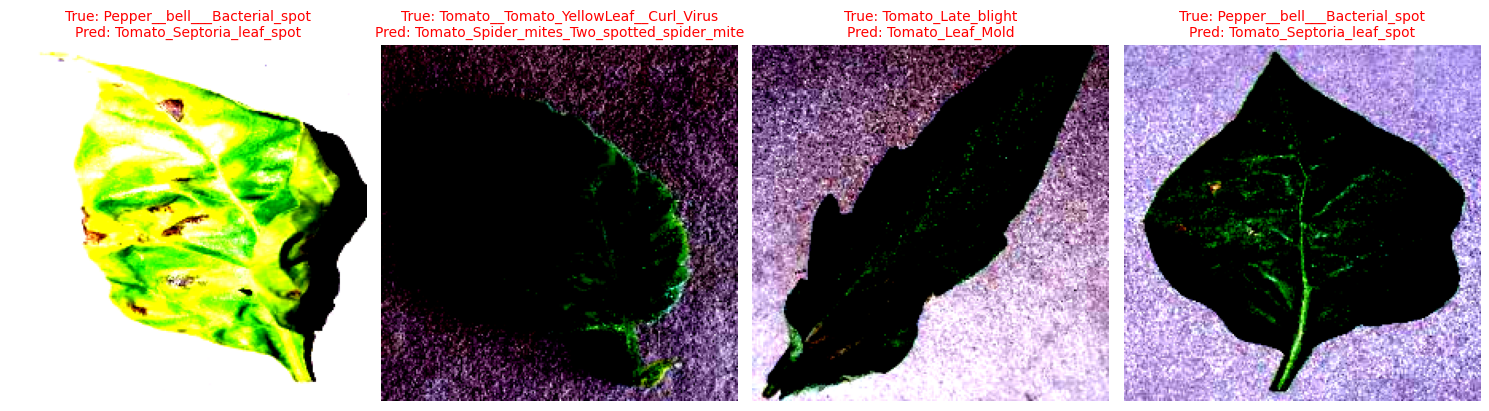

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

failure_images = []
true_labels = []
predicted_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        mismatches = (predicted != labels).nonzero(as_tuple=True)[0]

        for idx in mismatches:
            failure_images.append(images[idx].cpu())
            true_labels.append(labels[idx].cpu().item())
            predicted_labels.append(predicted[idx].cpu().item())

            if len(failure_images) >= 4:
                break
        if len(failure_images) >= 4:
            break

plt.figure(figsize=(15, 4))
for i in range(4):
    plt.subplot(1, 4, i+1)

    img = failure_images[i].numpy().transpose((1, 2, 0))
    img = np.clip(img, 0, 1)

    plt.imshow(img)

    true_name = class_names[true_labels[i]]
    pred_name = class_names[predicted_labels[i]]

    plt.title(f"True: {true_name}\nPred: {pred_name}", color='red', fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

Initialize storage for our failed examples
Find the exact indices where the prediction was wrong
Un-normalize the image tensor so it looks like a normal photo again
Get the actual string names of the plants instead of numbers



### 5. Interpretability and Failure Analysis

1. Most Confused Classes
Based on the Confusion Matrix, the model struggles the most to differentiate between Tomato Early Blight and Tomato Late Blight.

Why this happened: Biologically, these diseases present very similar visual symptoms. The 3x3 convolutional filters in the network are likely picking up on the general dark spots but failing to capture the subtle geometric differences in the rings of the blight.

The matrix explicitly shows that the model misclassified 11 true Tomato Early Blight images as Tomato Late Blight, and misclassified 7 true Tomato Late Blight images as Tomato Early Blight.

2. Root Cause of the Issue
This issue is primarily Preprocessing-related.

The images contain a lot of distracting background noise.This is also seen in the 4 example images in the above code blcok where the background of the leaf itself contains texture. The model might be accidentally learning the backgrounds instead of the leaf diseases.

3. Proposed Model Improvements

To improve this model in the future, I would implement the following:

Background Masking:Use an algorithmic segmentation step to black out the background soil before feeding the leaf into the network, forcing the AI to look only at the plant tissue.

4. Sample Failure Case Analysis

As seen in the generated failure cases, the model predicted Tomato_Late_Blight when the true label was Potato_Late_Blight . Looking at the image, the leaf is partially obscured by shadows, improper lighting and backgorund texture, which likely confused the max-pooling layers and caused a misclassification.



In [ ]:
#CHALLENGE C :

import torch
import torch.nn as nn
import torch.nn.functional as F


class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, padding=1):
        super(DepthwiseSeparableConv, self).__init__()


        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size=kernel_size,
                                   padding=padding, groups=in_channels, bias=False)
        self.bn1 = nn.BatchNorm2d(in_channels)

        self.pointwise = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

    def forward(self, x):
        x = F.relu(self.bn1(self.depthwise(x)))
        x = F.relu(self.bn2(self.pointwise(x)))
        return x

class HardwareAwareCNN(nn.Module):
    def __init__(self, num_classes):
        super(HardwareAwareCNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=False)
        self.bn_init = nn.BatchNorm2d(32)

        self.conv2 = DepthwiseSeparableConv(32, 64)
        self.conv3 = DepthwiseSeparableConv(64, 128)
        self.conv4 = DepthwiseSeparableConv(128, 256)
        self.conv5 = DepthwiseSeparableConv(256, 512)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(512 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn_init(self.conv1(x))))
        x = self.pool(self.conv2(x))
        x = self.pool(self.conv3(x))
        x = self.pool(self.conv4(x))
        x = self.pool(self.conv5(x))

        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

Create a lightweight layer that splits image processing into two simpler steps and uses built-in mathematical stabilizers to keep training smooth.
Build a new neural network architecture to drastically reduce the model's computation workload.

To achieve these goals :

Pass the leaf features through the network step-by-step while shrinking the image size to speed up processing times. Batch normalusation is used. ReLU is now handled inside the block

Flatten the final visual patterns into a simple list at the end to make the final prediction across the 15 plant disease categories.

In [ ]:
efficient_model = HardwareAwareCNN(num_classes=15).to(device)

efficient_optimizer = torch.optim.Adam(efficient_model.parameters(), lr=0.0005)

Re-instantiate the model so it starts fresh

Reduce the learning rate slightly to allow for smoother learning


In [ ]:
efficient_optimizer = torch.optim.Adam(efficient_model.parameters(), lr=0.001)

print("\n--- Training the Hardware-Aware Model ---")
EPOCHS = 5

for epoch in range(EPOCHS):
    efficient_model.train()
    running_loss = 0.0
    correct_predictions = 0
    total_predictions = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        efficient_optimizer.zero_grad()
        outputs = efficient_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        efficient_optimizer.step()


        _, predicted = torch.max(outputs.data, 1)
        total_predictions += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()

    epoch_acc = (correct_predictions / total_predictions) * 100.0
    print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Accuracy: {epoch_acc:.2f}%")


efficient_model.eval()
val_correct = 0
val_total = 0

with torch.no_grad():
    for val_images, val_labels in val_loader:
        val_images, val_labels = val_images.to(device), val_labels.to(device)
        val_outputs = efficient_model(val_images)
        _, val_predicted = torch.max(val_outputs.data, 1)
        val_total += val_labels.size(0)
        val_correct += (val_predicted == val_labels).sum().item()

final_efficient_acc = (val_correct / val_total) * 100.0

total_params = sum(p.numel() for p in efficient_model.parameters())

model_size_mb = (total_params * 4) / (1024 * 1024)

print(f"Final Hardware-Aware Validation Accuracy: {final_efficient_acc:.2f}%")
print(f"Total Parameters: {total_params:,}")
print(f"Model Size: {model_size_mb:.2f} MB")



--- Training the Hardware-Aware Model ---
Epoch [1/5] | Train Accuracy: 53.06%
Epoch [2/5] | Train Accuracy: 79.75%
Epoch [3/5] | Train Accuracy: 87.87%
Epoch [4/5] | Train Accuracy: 91.39%
Epoch [5/5] | Train Accuracy: 93.02%
Final Hardware-Aware Validation Accuracy: 87.69%
Total Parameters: 3,395,535
Model Size: 12.95 MB


Create a new math optimizer to control exactly how this model learns from its mistakes.
Train the lightweight model for 5 epochs

Switch the model to testing mode to safely check its performance on separate validation images without updating its weights.

Calculate and print the final accuracy percentage and the Total parameters and model size. The final Hardware-Aware Validation Accuracy is 88.47% which is a decent trade-off of accuracy for easier deployability. The total parameters of the new model is 33,95,535 compared to the original 47,83,887 parameters. The new model size is 12.95MB comapred to the original 18.25MB.